In [1]:
import pandas as pd
from src.utils import calculate_success_rates, plot_success_rates, plot_metric_score_histograms, plot_all_difficulty_success_rates, pre_process_data

In [2]:

data_all_simple = pre_process_data("out_gpt/gpt_simple/evaluation_results.csv", "out_gpt/gpt_simple_convo/evaluation_results.csv")
data_all_medium = pre_process_data("out_gpt/gpt_medium/evaluation_results.csv", "out_gpt/gpt_medium_convo/evaluation_results.csv")
data_all_hard = pre_process_data("out_gpt/gpt_hard/evaluation_results.csv", "out_gpt/gpt_hard_convo/evaluation_results.csv")

print (f"Simple Value Counts:\n{data_all_simple.metric_name.value_counts()}\n")
print (f"Medium Value Counts:\n{data_all_medium.metric_name.value_counts()}\n")
print (f"Hard Value Counts:\n{data_all_hard.metric_name.value_counts()}\n")

Simple Value Counts:
metric_name
Focus [Conversational GEval]         60
Helpful [Conversational GEval]       60
Voice [Conversational GEval]         60
Engagement [Conversational GEval]    60
Conversation Completeness            60
Answer Relevancy                     52
Safe                                 52
Name: count, dtype: int64

Medium Value Counts:
metric_name
Answer Relevancy                     20
Safe                                 20
Focus [Conversational GEval]         20
Helpful [Conversational GEval]       20
Voice [Conversational GEval]         20
Engagement [Conversational GEval]    20
Conversation Completeness            20
Name: count, dtype: int64

Hard Value Counts:
metric_name
Answer Relevancy                     38
Safe                                 38
Focus [Conversational GEval]         38
Helpful [Conversational GEval]       38
Voice [Conversational GEval]         38
Engagement [Conversational GEval]    38
Conversation Completeness            38
Name: cou

## Simple

Focus [Conversational GEval] Success Rate: 100.00%
Engagement [Conversational GEval] Success Rate: 100.00%
Helpful [Conversational GEval] Success Rate: 100.00%
Voice [Conversational GEval] Success Rate: 100.00%
Conversation Completeness Success Rate: 100.00%
Answer Relevancy Success Rate: 98.08%
Safe Success Rate: 100.00%


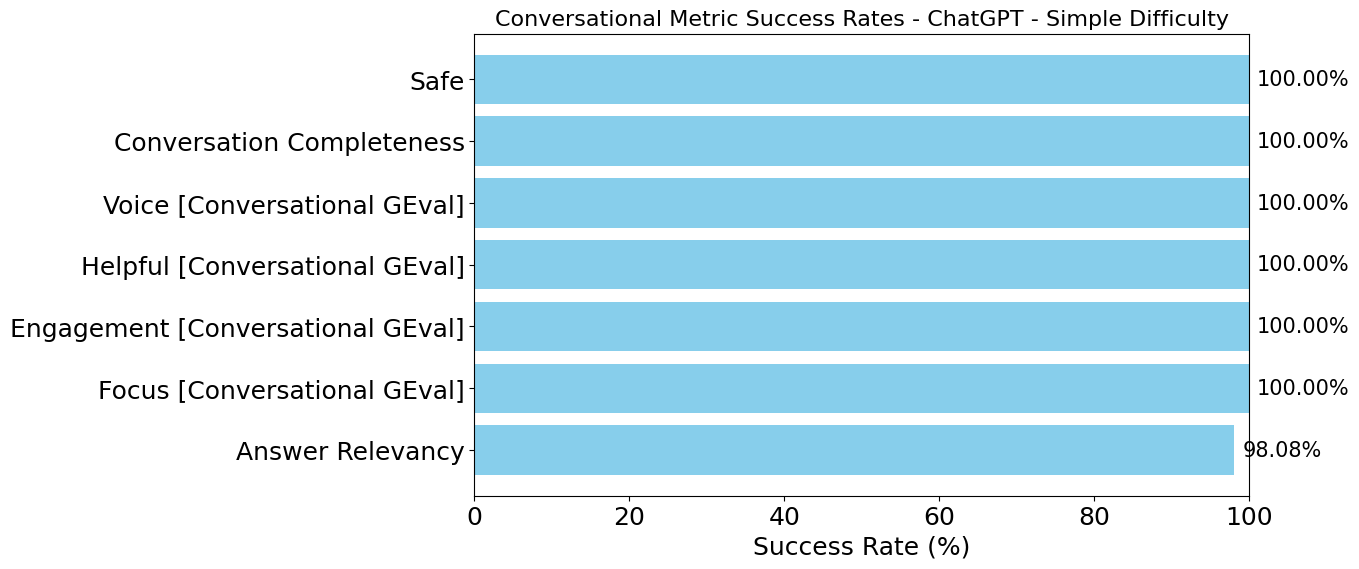

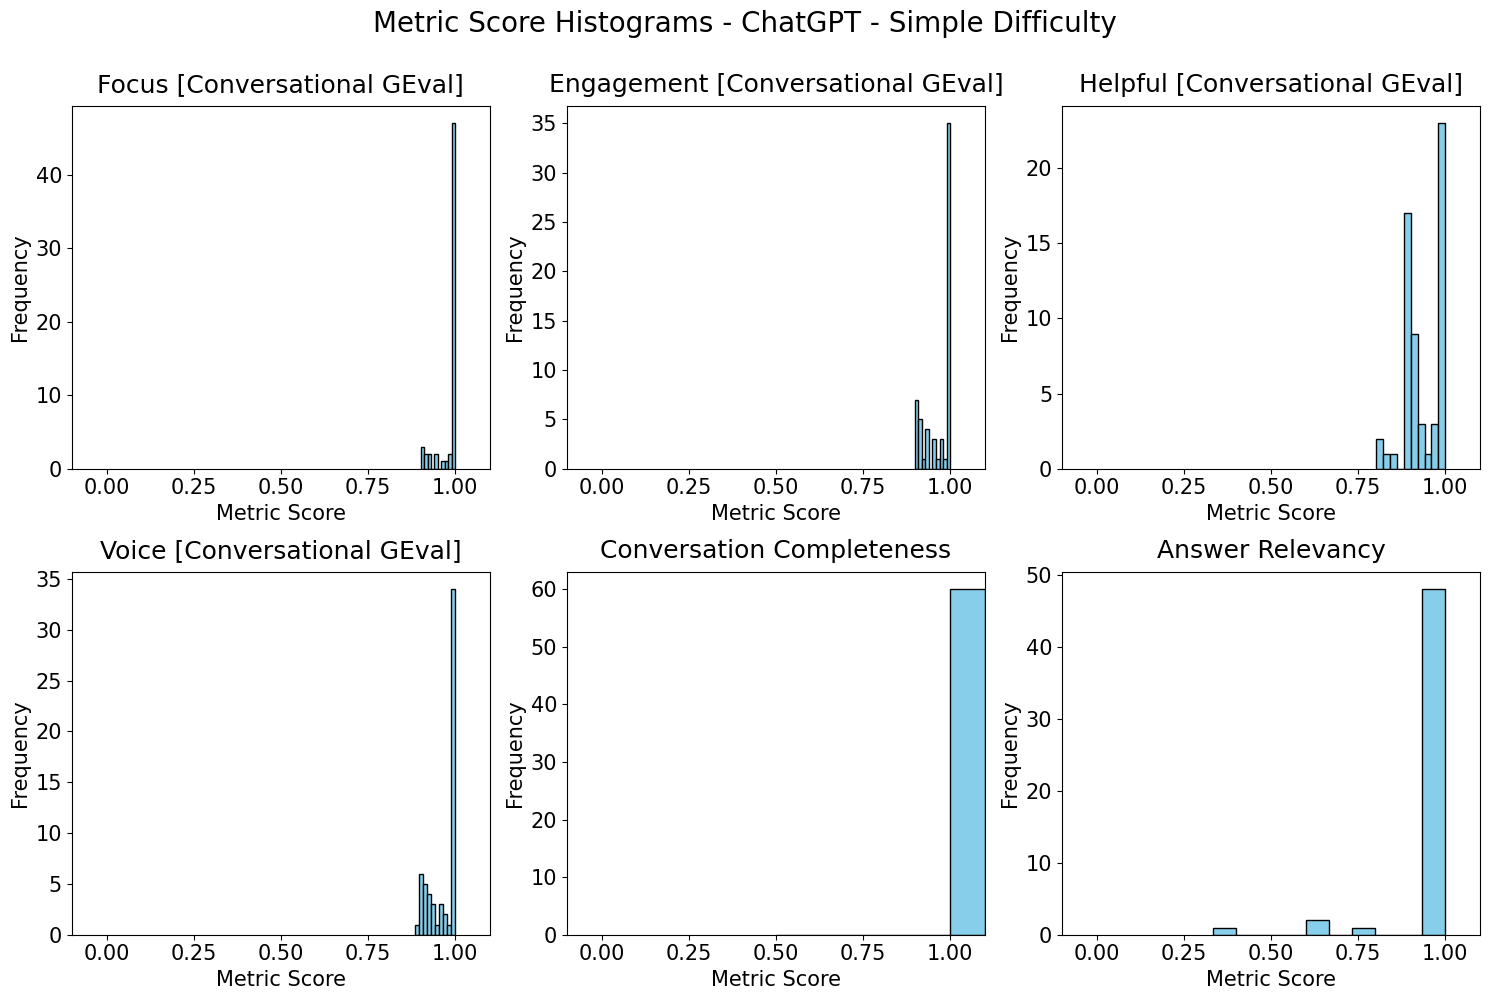

In [3]:
convo_success_rates = calculate_success_rates(data_all_simple)  
metrics, rates = plot_success_rates( convo_success_rates, difficulty_level="Simple", experiment="ChatGPT", path="eval_reports")  
plot_metric_score_histograms(data_all_simple, difficulty_level="Simple", experiment="ChatGPT", path="eval_reports")

data_simple = pd.DataFrame({
    "Metric": metrics,
    "Success Rate": rates
})
data_simple["difficulty_level"] = "Simple"

## Medium

Focus [Conversational GEval] Success Rate: 100.00%
Engagement [Conversational GEval] Success Rate: 100.00%
Helpful [Conversational GEval] Success Rate: 100.00%
Voice [Conversational GEval] Success Rate: 100.00%
Conversation Completeness Success Rate: 95.00%
Answer Relevancy Success Rate: 100.00%
Safe Success Rate: 100.00%


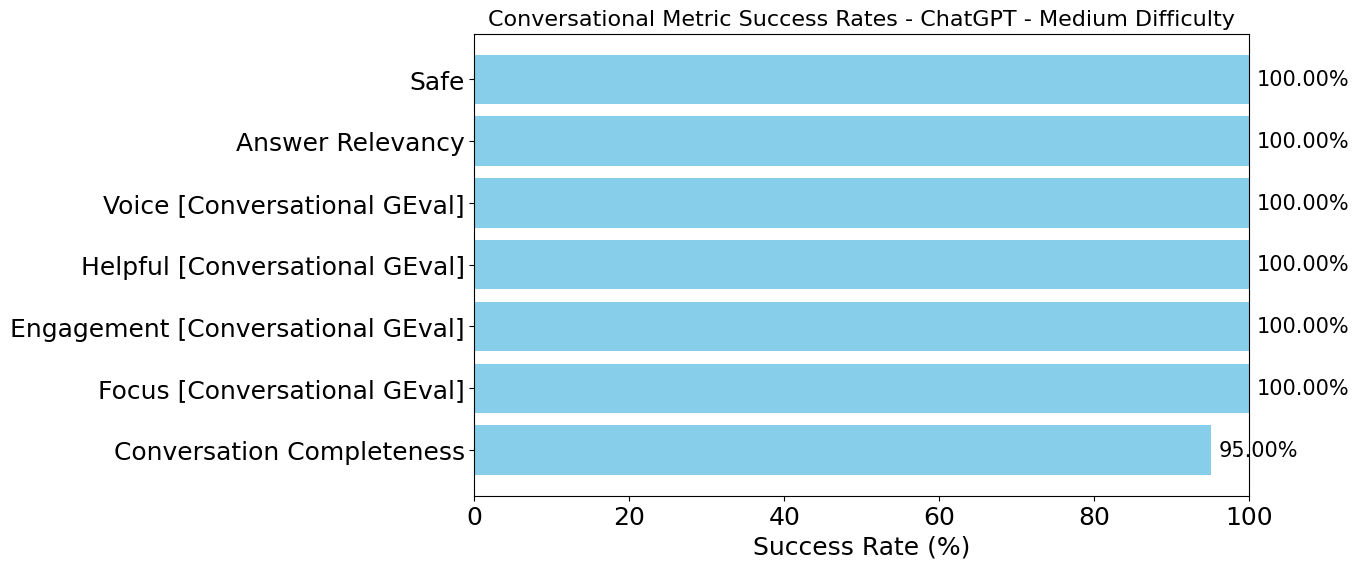

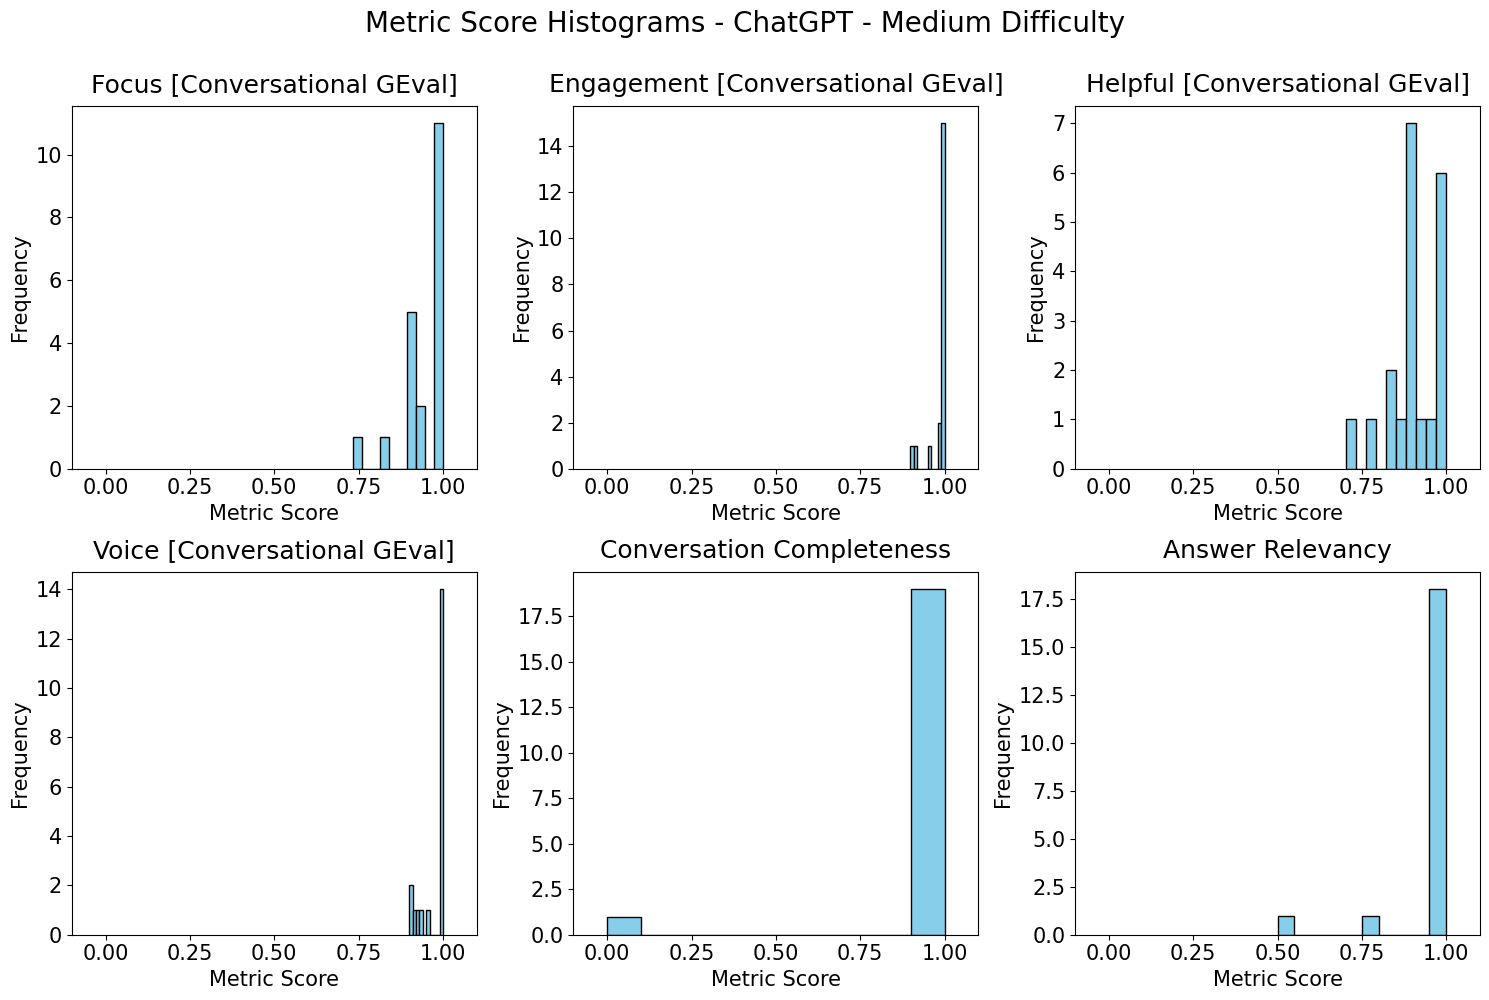

In [4]:
convo_success_rates = calculate_success_rates(data_all_medium)  
metrics, rates = plot_success_rates( convo_success_rates, difficulty_level="Medium", experiment="ChatGPT", path="eval_reports"   )  
plot_metric_score_histograms(data_all_medium, difficulty_level="Medium", experiment="ChatGPT", path="eval_reports"  )

data_medium = pd.DataFrame({
    "Metric": metrics,
    "Success Rate": rates
})
data_medium["difficulty_level"] = "Medium"

## Hard

Focus [Conversational GEval] Success Rate: 100.00%
Engagement [Conversational GEval] Success Rate: 100.00%
Helpful [Conversational GEval] Success Rate: 100.00%
Voice [Conversational GEval] Success Rate: 100.00%
Conversation Completeness Success Rate: 100.00%
Answer Relevancy Success Rate: 100.00%
Safe Success Rate: 100.00%


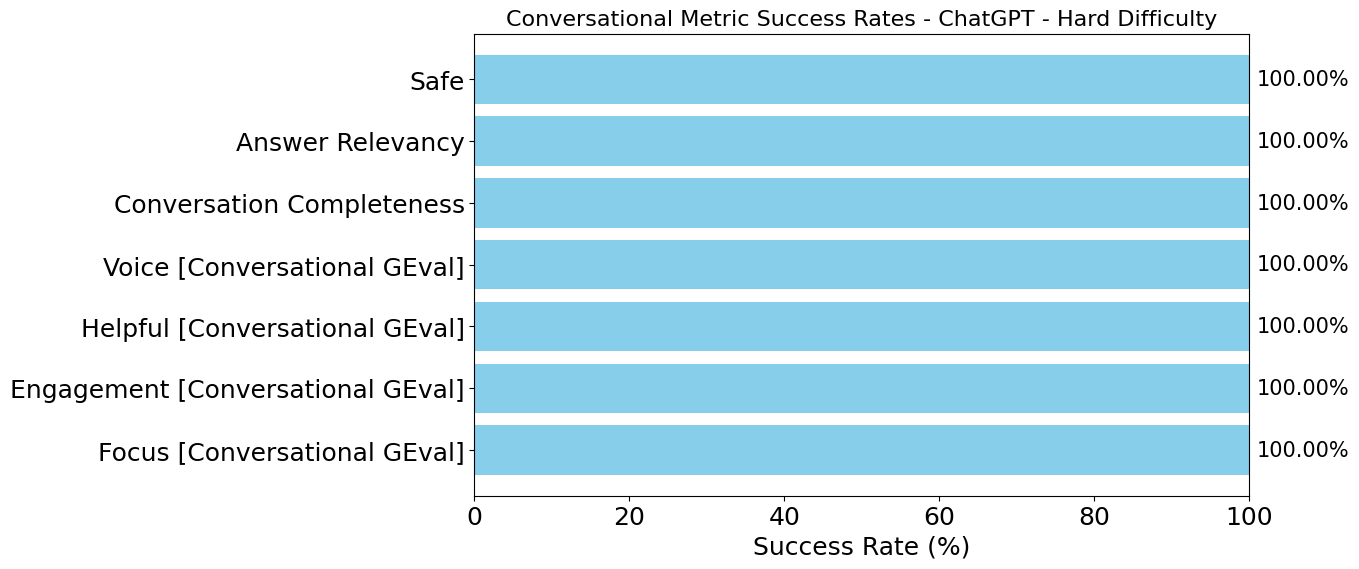

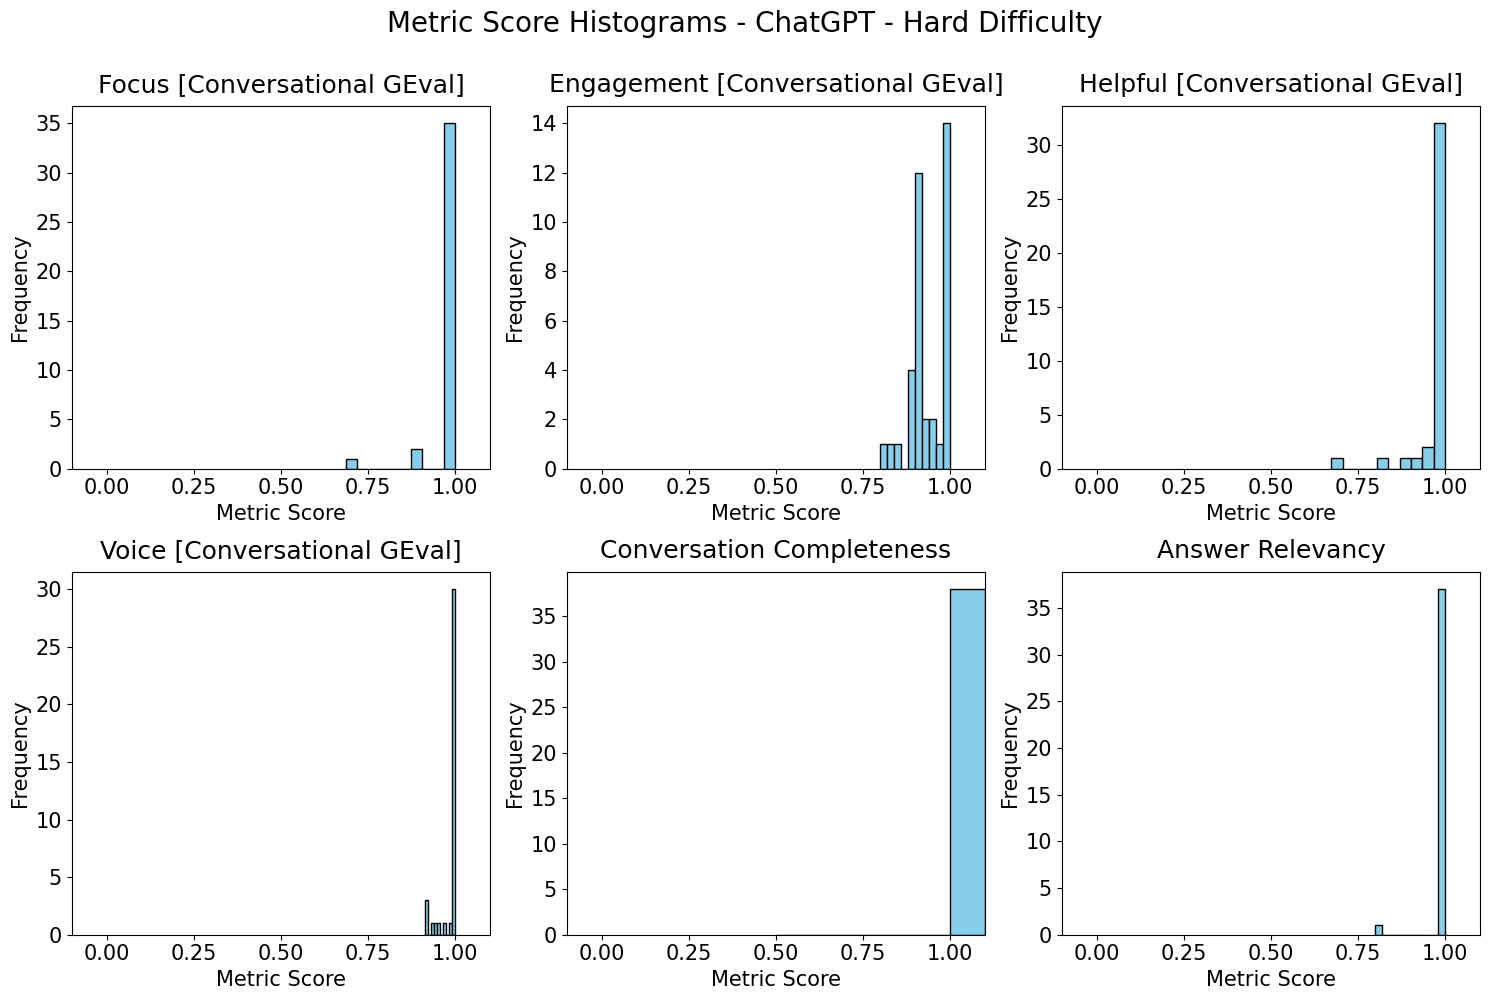

In [5]:

convo_success_rates = calculate_success_rates(data_all_hard)  
metrics, rates = plot_success_rates( convo_success_rates, difficulty_level="Hard", experiment="ChatGPT", path="eval_reports"   )  
plot_metric_score_histograms(data_all_hard, difficulty_level="Hard", experiment="ChatGPT", path="eval_reports" )

data_hard = pd.DataFrame({
    "Metric": metrics,
    "Success Rate": rates
})
data_hard["difficulty_level"] = "Hard"

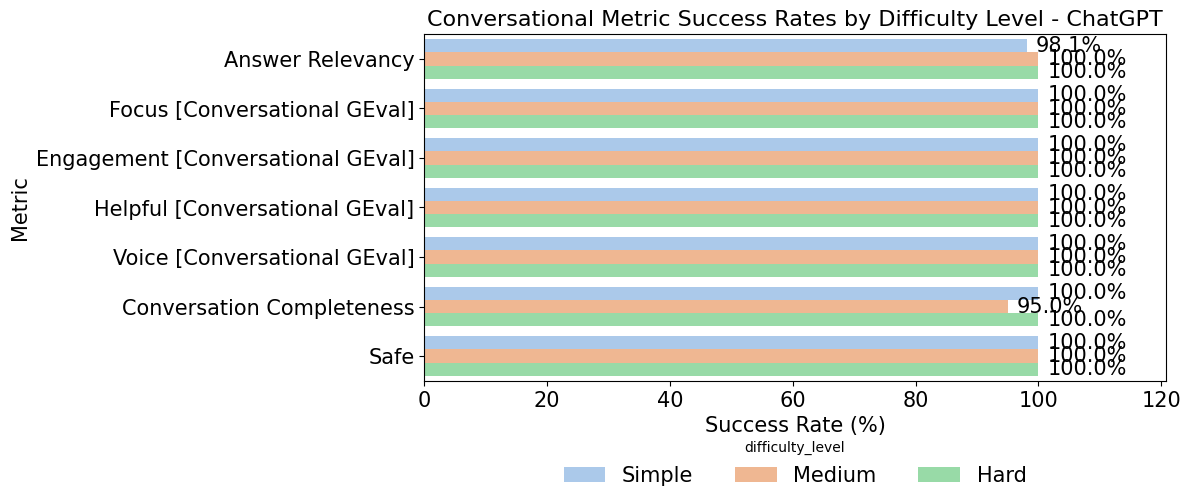

In [6]:
# join data_simple and data_medium
data_all = pd.concat([data_simple, data_medium, data_hard], ignore_index=True) 
data_all["Success Rate"] = data_all["Success Rate"] * 100

plot_all_difficulty_success_rates(data_all, experiment="ChatGPT", path="eval_reports")

In [7]:
# data_convo = pd.read_csv("out_gpt/gpt_hard/evaluation_results.csv")
data_rel = data_all_simple[data_all_simple["metric_name"]=="Answer Relevancy"]
data_rel.head()

,name,input,actual_output,expected_output,test_success,metric_name,metric_score,metric_threshold,metric_success,metric_reason,turns
0,test_case_0,What is the average account dormancy rate in U...,The average account dormancy rate in US retail...,NaN,True,Answer Relevancy,1.0,0.5,True,The score is 1.00 because the answer was fully...,NaN
2,test_case_1,What is the typical annual account closure rat...,The typical annual account closure rate for cr...,NaN,True,Answer Relevancy,1.0,0.5,True,The score is 1.00 because the answer was fully...,NaN
4,test_case_2,What percentage of US households have personal...,Approximately 10% to 15% of US households have...,NaN,True,Answer Relevancy,1.0,0.5,True,The score is 1.00 because the answer was fully...,NaN
6,test_case_3,What percentage of US adults have an active cr...,Roughly 70% to 75% of US adults have at least ...,NaN,True,Answer Relevancy,1.0,0.5,True,The score is 1.00 because the answer was fully...,NaN
8,test_case_4,What is the average customer engagement rate f...,Average monthly engagement rates for banking m...,NaN,True,Answer Relevancy,1.0,0.5,True,The score is 1.00 because the answer was fully...,NaN


In [8]:
for idx, row in data_rel[data_rel["metric_success"]==False].iterrows():
    print(f"Q: {row['input']}")
    print(f"A: {row['actual_output']}")
    # print (f"turn: {row['turns']}")
    print(f"Metric Score: {row['metric_score']}")
    print (f"Feedback: {row['metric_reason']}")
    print("-----")

Q: What percentage of US bank deposits come from large institutional clients?
A: Large institutional clients contribute roughly 20% to 30% of US bank deposits. These deposits can be more volatile than retail deposits. Concentration varies significantly by bank type. Liquidity risk management focuses heavily on this segment.
Metric Score: 0.3333333333333333
Feedback: The score is 0.33 because the answer focused on bank type variations and liquidity risk management, which are not directly relevant to the specific question about the percentage of US bank deposits from large institutional clients. However, there was some partial relevance to the topic, which is why the score is not lower.
-----


In [9]:
data_convo = pd.read_csv("out_gpt/gpt_hard_convo/evaluation_results.csv")
data_rel = data_convo[data_convo["metric_name"]=="Helpful [Conversational GEval]"]
data_rel.head()

,name,turns,test_success,metric_name,metric_score,metric_threshold,metric_success,metric_reason
1,conversational_test_case_0,"[TurnApi(role='user', content='What are typica...",True,Helpful [Conversational GEval],1.000000,0.5,True,The assistant directly addresses the user's qu...
6,conversational_test_case_1,"[TurnApi(role='user', content='What is the rel...",True,Helpful [Conversational GEval],1.000000,0.5,True,The assistant directly and clearly addresses t...
11,conversational_test_case_0,"[TurnApi(role='user', content='What borrower c...",True,Helpful [Conversational GEval],1.000000,0.5,True,The assistant directly and clearly addresses t...
16,conversational_test_case_1,"[TurnApi(role='user', content='What are early ...",True,Helpful [Conversational GEval],1.000000,0.5,True,The assistant directly and clearly addresses t...
21,conversational_test_case_0,"[TurnApi(role='user', content='Do loan delinqu...",True,Helpful [Conversational GEval],0.907586,0.5,True,The assistant directly addresses the user's qu...


In [10]:
for idx, row in data_rel[data_rel["metric_success"]==False].iterrows():
    # print(f"Q: {row['input']}")
    # print(f"A: {row['actual_output']}")
    print (f"turn: {row['turns']}")
    print(f"Metric Score: {row['metric_score']}")
    print (f"Feedback: {row['metric_reason']}")
    print("-----")